# Descrição do Problema

O presente trabalho tem como objetivo analisar um conjunto de dados de clientes de uma empresa de telecomunicações, com foco em entender o o que influencia o cancelamento dos clientes (churn)

O churn é a saída de clientes da base da empresa, sendo um problema para o negócio, pois impacta diretamente a receita e os custos de aquisição(CAC) de novos clientes.



## Hipóteses do Problema

As hipóteses levantadas são as seguintes:

1) Clientes com contratos mensais possuem maior probabilidade de churn?
2) Clientes com menor tempo de permanência (tenure) tendem a cancelar mais?
3) Clientes com menos serviços contratados podem ter maior churn?
4) Valores mais altos de mensalidade podem influenciar o cancelamento?


## Tipo de Problema

Este problema é caracterizado como um problema de aprendizado supervisionado, uma vez que tem uma variável de estudo (Churn) indicando se o cliente cancelou ou não o serviço.


## Seleção de Dados

O dataset utilizado foi obtido a partir do Kaggle para análise de churn em empresas de telecomunicações.

Os dados já se encontram estruturados e organizados, contendo informações relevantes sobre clientes, como características demográficas, serviços contratados, informações contratuais e valores financeiros.

Não foi necessária a integração com outras fontes de dados, uma vez que o dataset possui variáveis suficientes para a análise proposta.

A seleção das variáveis considerou atributos com potencial impacto no churn, como tempo de contrato (tenure), tipo de contrato (Contract), valor mensal (MonthlyCharges) e serviços contratados, permitindo uma análise abrangente do comportamento dos clientes.

## Atributos do Dataset

- customerID: identificador único do cliente
- gender: gênero do cliente
- SeniorCitizen: indica se o cliente é idoso
- Partner: se possui parceiro
- Dependents: se possui dependentes
- tenure: tempo de permanência (meses)
- PhoneService: possui serviço de telefone
- MultipleLines: múltiplas linhas
- InternetService: tipo de internet
- OnlineSecurity: possui segurança online
- OnlineBackup: possui backup online
- DeviceProtection: proteção de dispositivo
- TechSupport: suporte técnico
- StreamingTV: streaming de TV
- StreamingMovies: streaming de filmes
- Contract: tipo de contrato
- PaperlessBilling: cobrança digital
- PaymentMethod: forma de pagamento
- MonthlyCharges: valor mensal
- TotalCharges: valor total pago
- Churn: **variável alvo **(cancelou ou não)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção reúne as bibliotecas utilizadas ao longo da análise, incluindo ferramentas para manipulação de dados, visualização e pré-processamento.

Além disso, é realizado o carregamento do dataset de churn, que servirá como base para todas as etapas do estudo.

O dataset foi importado diretamente do Kaggle, garantindo reprodutibilidade e evitando dependência de arquivos locais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Análise de Dados

O dataset possui aproximadamente 7.000 registros e mais de 20 atributos.

Observa-se a presença de variáveis categóricas e numéricas, sendo a variável alvo "Churn".

Algumas variáveis aparentam necessitar de tratamento, especialmente no que diz respeito aos tipos de dados e possíveis valores ausentes.

In [3]:
df = pd.read_csv('/content/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


A visualização das primeiras linhas permite além de identificar a estrutura do dataset, as possíveis inconsistências iniciais nos dados.

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


A análise de valores ausentes indica que a variável TotalCharges apresenta inconsistências, possivelmente devido a registros vazios ou com tipo incorreto.

Será necessário tratar essa variável durante a etapa de pré-processamento.

In [7]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869



Observa-se um desequilíbrio entre as classes, com maior proporção de clientes que não realizaram churn.

Esse comportamento pode impactar análises futuras e indica a necessidade de atenção em modelos preditivos.


## Total e Tipo das Instâncias

O dataset analisado possui 7043 instâncias (observações), representando clientes de uma empresa de telecomunicações.

Ao todo, o conjunto de dados contém 21 atributos, incluindo variáveis demográficas, contratuais e financeiras.

Em relação aos tipos de dados, observa-se que:

- A maior parte das variáveis é do tipo categórico (object), como gênero, tipo de contrato e serviços contratados.
- Algumas variáveis são numéricas, como:
  - **tenure** (tempo de contrato)
  - **MonthlyCharges** (valor mensal)
  - **TotalCharges** (valor total acumulado)
- A variável **SeniorCitizen** aparece como numérica (int64), mas representa uma categoria binária (0 ou 1).

Essa diversidade de tipos de dados indica a necessidade de etapas de pré-processamento, como encoding para variáveis categóricas e padronização para variáveis numéricas.

In [9]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 7043

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   o

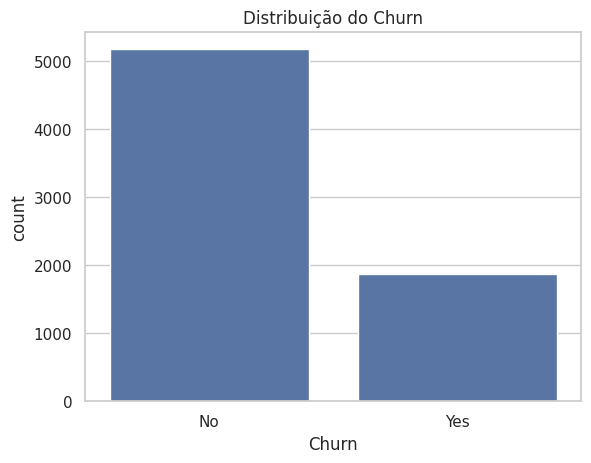

In [10]:
sns.countplot(x='Churn', data=df)
plt.title('Distribuição do Churn')
plt.show()

Observa-se que a maioria dos clientes não realizou churn, porém há uma parcela significativa de clientes que cancelaram o serviço, indicando um possível desbalanceamento de classes.

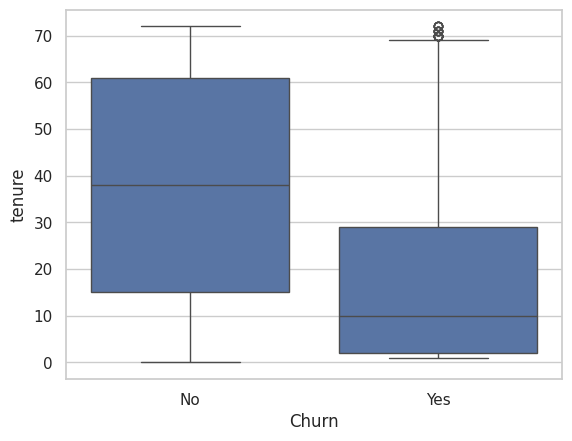

In [11]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

Clientes que realizaram churn tendem a apresentar menor tempo de permanência (tenure), indicando que novos clientes possuem maior propensão ao cancelamento.

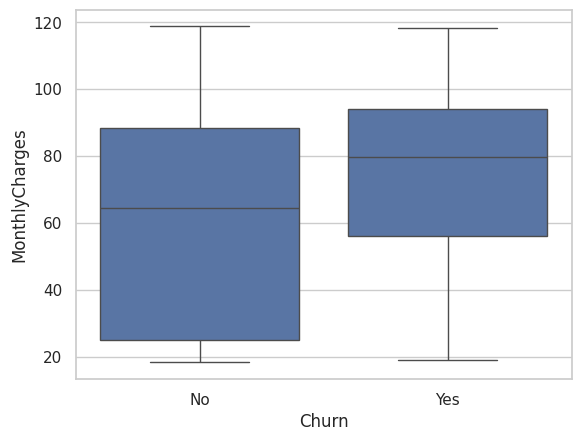

In [12]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

Clientes com churn apresentam, em média, valores mensais mais elevados, sugerindo que preços mais altos podem estar relacionados à evasão de clientes.

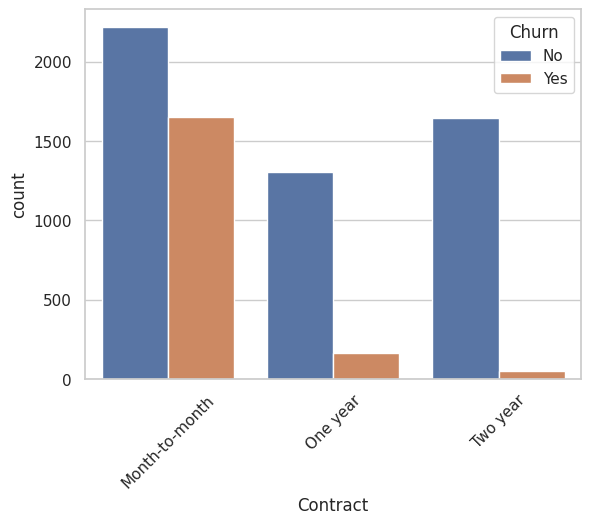

In [13]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

Clientes com contrato mensal apresentam maior incidência de churn, enquanto contratos de longo prazo demonstram maior retenção.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [14]:
# estatísticas descritivas básicas do dataset
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [15]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
SeniorCitizen,0.162147
tenure,32.371149
MonthlyCharges,64.761692


### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [16]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

,std
SeniorCitizen,0.368612
tenure,24.559481
MonthlyCharges,30.090047


## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

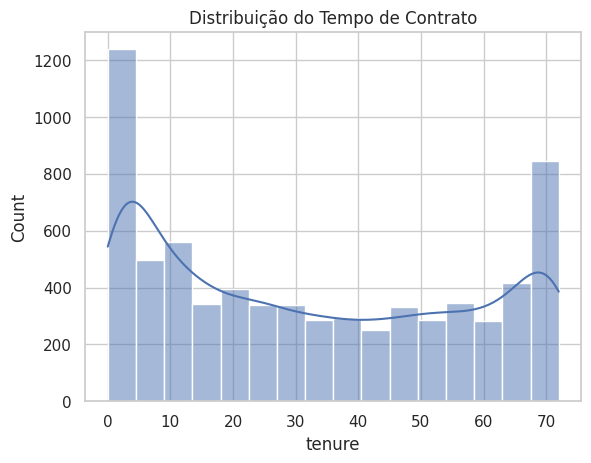

In [18]:
sns.histplot(df['tenure'], kde=True)
plt.title('Distribuição do Tempo de Contrato')
plt.show()


Observa-se que a maioria dos clientes possui baixo tempo de contrato (tenure), indicando alta entrada recente de clientes.

Além disso, a distribuição sugere uma concentração maior em períodos iniciais, o que pode estar associado a maior risco de churn nos primeiros meses.

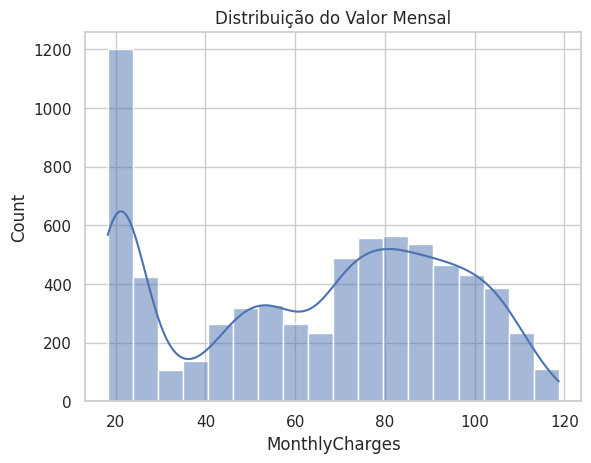

In [19]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title('Distribuição do Valor Mensal')
plt.show()


Os valores mensais apresentam distribuição relativamente ampla, com concentração em faixas intermediárias.

Clientes com valores mais elevados podem ter maior expectativa de serviço, o que pode impactar diretamente na decisão de cancelamento.

## Boxplot



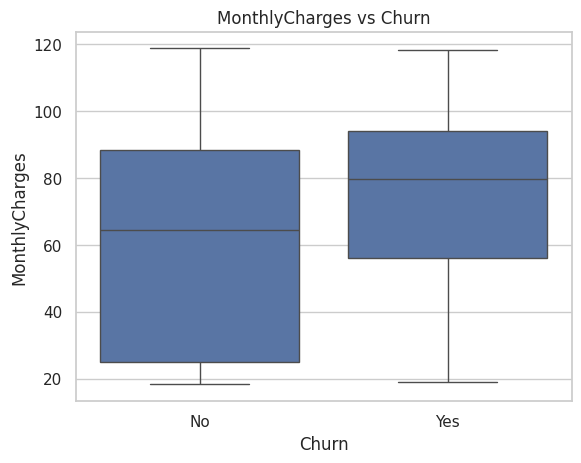

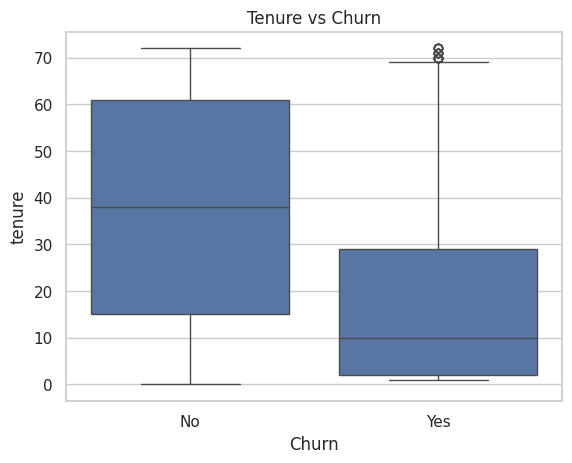

In [22]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('MonthlyCharges vs Churn')
plt.show()
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

Observa-se que clientes que realizam churn apresentam, em média, menor tempo de contrato e valores mensais mais elevados.

Isso reforça a hipótese de que clientes novos e com maior custo são mais propensos ao cancelamento.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

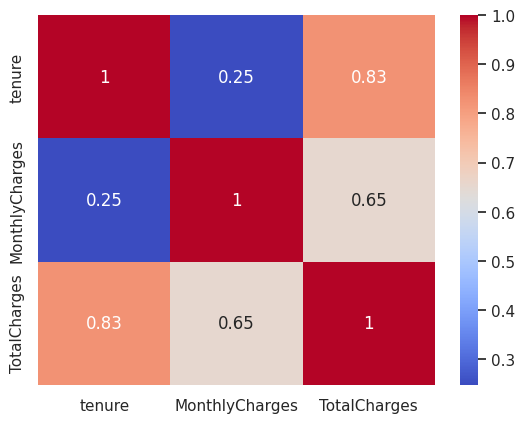

In [24]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

corr = df[['tenure','MonthlyCharges','TotalCharges']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


A matriz de correlação indica relação moderada entre algumas variáveis financeiras, como MonthlyCharges e TotalCharges.

No entanto, não há correlações extremamente fortes, indicando que o churn pode ser influenciado por múltiplos fatores combinados.

## Tratamento de Valores Nulos

## Tratamento de Valores Nulos

Durante a análise dos dados, foi identificado que a variável **TotalCharges** apresentava valores ausentes.

Esses valores nulos estão relacionados a clientes com pouco tempo de contrato (tenure igual a zero), o que indica que ainda não houve cobrança acumulada.

Para garantir a consistência dos dados e evitar problemas nas análises, optou-se por remover os registros com valores nulos, uma vez que representam uma pequena parcela do dataset e não comprometem a análise geral.

Essa abordagem permite trabalhar com um conjunto de dados limpo e confiável para as etapas seguintes.

In [ ]:
df.isnull().sum()

df.dropna(inplace=True)
print("Valores nulos no dataset:")
df.isnull().sum()

Os valores ausentes foram tratados utilizando a mediana da variável, evitando a influência de possíveis outliers. A substituição foi realizada diretamente na coluna, garantindo a consistência dos dados.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

## Tratamento de Dados

Nesta etapa, realizamos a limpeza dos dados, tratando valores ausentes e ajustando tipos de variáveis quando necessário.

In [49]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

## Encoding

Variáveis categóricas foram convertidas em formato numérico utilizando a técnica de one-hot encoding.

In [50]:
df_encoded = pd.get_dummies(df, drop_first=True)

## Normalização

In [54]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()

df_normalized = df.copy()

df_normalized[numeric_cols] = scaler_minmax.fit_transform(df[numeric_cols])

df_normalized.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,0.000000,0.115423,0.001275,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,0.464789,0.385075,0.215867,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,0.014085,0.354229,0.010310,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,0.619718,0.239303,0.210241,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,0.014085,0.521891,0.015330,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True



Após a aplicação da normalização, observa-se que as variáveis numéricas passaram a assumir valores em uma mesma escala, variando entre 0 e 1.

Essa transformação facilita a comparação entre atributos que originalmente possuíam magnitudes diferentes, como tempo de contrato e valores monetários.

Além disso, a normalização contribui para reduzir possíveis distorções em análises futuras, especialmente em modelos que são sensíveis à escala dos dados.

## Padronização

In [55]:
from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()

df_standardized = df.copy()
df_standardized[numeric_cols] = scaler_standard.fit_transform(df[numeric_cols])

df_standardized.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,-1.280248,-1.161694,-0.994194,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,0.064303,-0.260878,-0.173740,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,-1.239504,-0.363923,-0.959649,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,0.512486,-0.747850,-0.195248,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,-1.239504,0.196178,-0.940457,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True



Com a padronização, os dados passaram a apresentar média próxima de zero e desvio padrão igual a um, o que permite uma melhor distribuição das variáveis.

Essa técnica é especialmente útil quando se deseja analisar o comportamento relativo dos dados, eliminando o impacto da escala original.

A padronização também é importante para algoritmos de machine learning que assumem distribuição normal dos dados, contribuindo para maior estabilidade e desempenho dos modelos.

### Comparação entre as Técnicas

Enquanto a normalização ajusta os dados para um intervalo fixo, a padronização transforma os dados com base em sua distribuição estatística.

A escolha entre essas técnicas depende do objetivo da análise e do tipo de modelo a ser utilizado, sendo ambas importantes etapas no pré-processamento de dados.

# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

In [ ]:

-Clientes com menor tempo de contrato apresentam maior churn.
→ Confirmada: clientes com baixo tenure possuem maior taxa de saída.

## Hipótese 2

In [ ]:
Contratos mensais apresentam maior churn.
→ Confirmada: modelo month-to-month apresenta maior churn.

## Hipótese 3

In [ ]:
Clientes com maior valor mensal têm maior churn.
→ Parcialmente confirmada: clientes com cobrança elevada tendem a churn, mas não é fator isolado.

# Conclusão

A análise demonstrou que o churn está fortemente associado a:

- Baixo tempo de relacionamento
- Contratos mensais
- Maior valor mensal

Esses fatores indicam que clientes em estágio inicial e com maior custo são mais sensíveis ao cancelamento.

Do ponto de vista estratégico, recomenda-se:

- Incentivar contratos de longo prazo
- Criar ações de retenção nos primeiros meses
- Revisar estratégias de pricing

Como próximos passos, sugere-se a construção de modelos preditivos para antecipação de churn.